In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODELS = ["LR", "RF", "SVM", "XGB"]

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR     = PROJECT_ROOT / "data"

PRED_FILE = DATA_DIR / "05_scaling_no_ever_preds.csv"
OHE_FILE  = DATA_DIR / "05_data_OHE.csv"

In [3]:
preds = pd.read_csv(PRED_FILE)

print("rows  :", len(preds))
print("strata:", preds["Strata"].nunique())
print("labels:", preds["osteo_label"].value_counts().to_dict())

assert len(preds) == 2 * preds["Strata"].nunique()

rows  : 61026
strata: 30513
labels: {0: 30513, 1: 30513}


# Check decision threshold

In [4]:
def PAIR_FRAME(preds, model):
    """One row per stratum: the case's probability and its matched control's."""
    wide = preds.pivot(index="Strata",
                       columns="osteo_label",
                       values=f"{model}_prob")
    wide.columns = ["ctrl_prob", "case_prob"]
    wide["margin"] = wide["case_prob"] - wide["ctrl_prob"]
    return wide


pairs = {m: PAIR_FRAME(preds, m) for m in MODELS}

for m in MODELS:
    print(f"{m}: pair_acc = {(pairs[m]['margin'] > 0).mean():.4f}")

LR: pair_acc = 0.7469
RF: pair_acc = 0.7840
SVM: pair_acc = 0.7364
XGB: pair_acc = 0.7865


In [9]:
pairs

{'LR':         ctrl_prob  case_prob    margin
 Strata                                
 1        0.192607   0.770783  0.578176
 2        0.519837   0.447488 -0.072348
 3        0.380150   0.266590 -0.113560
 4        0.692890   0.439679 -0.253212
 5        0.399158   0.382123 -0.017036
 ...           ...        ...       ...
 30513    0.608264   0.451814 -0.156451
 30514    0.657134   0.797754  0.140620
 30515    0.434292   0.332481 -0.101811
 30516    0.449009   0.388368 -0.060641
 30517    0.479299   0.369457 -0.109842
 
 [30513 rows x 3 columns],
 'RF':         ctrl_prob  case_prob    margin
 Strata                                
 1        0.156181   0.569091  0.412910
 2        0.507118   0.462643 -0.044475
 3        0.276822   0.355639  0.078816
 4        0.575278   0.513849 -0.061430
 5        0.363346   0.333034 -0.030312
 ...           ...        ...       ...
 30513    0.248221   0.428232  0.180011
 30514    0.612889   0.682479  0.069590
 30515    0.441170   0.467732  0.026562

# predicted-probability distribution by class — that shows how the two classes overlap

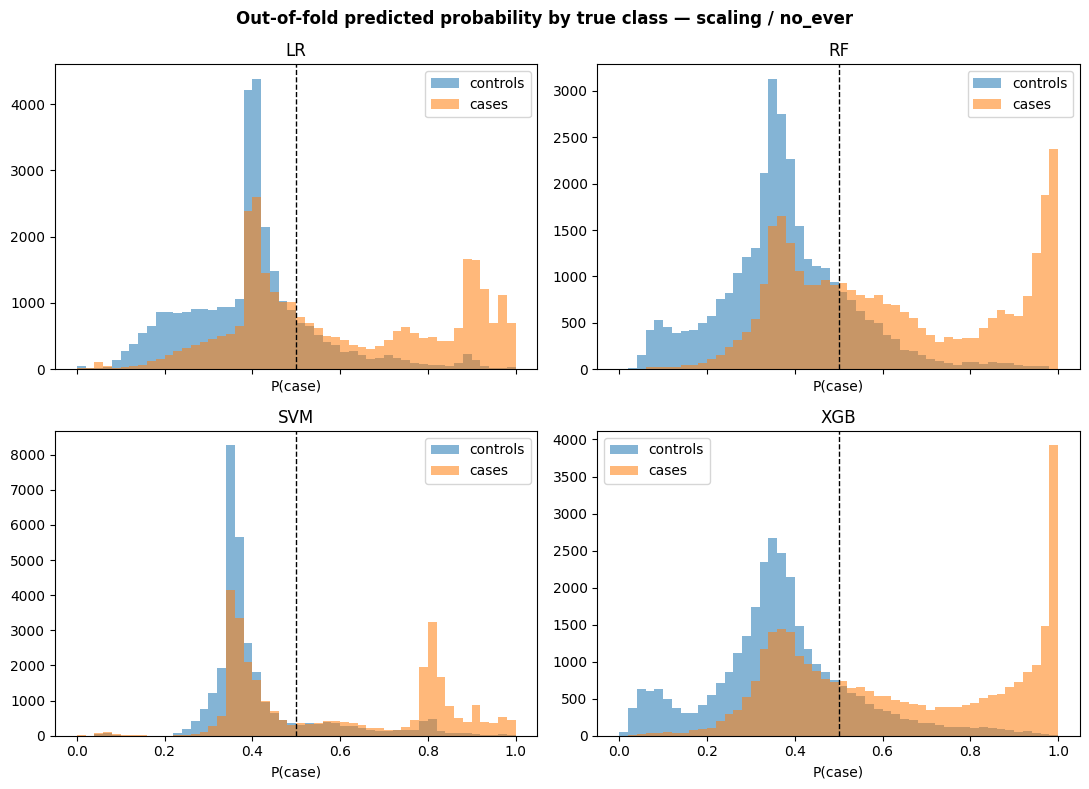

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

for ax, m in zip(axes.ravel(), MODELS):
    for label, name in [(0, "controls"), (1, "cases")]:
        ax.hist(preds.loc[preds["osteo_label"] == label, f"{m}_prob"],
                bins=50, range=(0, 1), alpha=0.55, label=name)
    ax.axvline(0.5, color="k", linestyle="--", linewidth=1)
    ax.set_title(m)
    ax.set_xlabel("P(case)")
    ax.legend()

fig.suptitle("Out-of-fold predicted probability by true class — scaling / no_ever",
             fontweight="bold")
fig.tight_layout()
plt.show()

`Controls` form one tight **unimodal** cluster around 0.35–0.40. `Cases` split into two groups: one overlapping the `control` cluster almost exactly, and a second at the high end — 0.9+ in LR and XGB, 0.8 in SVM, pinned at 1.0 in RF.

In [6]:
summary = []
for m in MODELS:
    for label, name in [(1, "cases"), (0, "controls")]:
        p = preds.loc[preds["osteo_label"] == label, f"{m}_prob"]
        summary.append({"model": m, "class": name,
                        "median": p.median(),
                        "q25": p.quantile(0.25),
                        "q75": p.quantile(0.75),
                        "frac_above_0.5": (p > 0.5).mean()})

print(pd.DataFrame(summary).set_index(["model", "class"]).round(3))

                median    q25    q75  frac_above_0.5
model class                                         
LR    cases      0.534  0.405  0.861           0.542
      controls   0.400  0.306  0.452           0.170
RF    cases      0.571  0.403  0.875           0.599
      controls   0.367  0.299  0.456           0.176
SVM   cases      0.521  0.370  0.808           0.512
      controls   0.366  0.350  0.416           0.162
XGB   cases      0.587  0.394  0.909           0.593
      controls   0.358  0.284  0.443           0.169


> The cases are bimodal in every model. The controls are not.

> What we have is a subgroup of cases the models identify confidently and a subgroup they can't distinguish from controls at all.

## what separates the two `case` modes?

In [7]:
data_OHE = pd.read_csv(OHE_FILE)

FEATURE_COLS = [c for c in data_OHE.columns
                if c not in ("Strata", "osteo_label")]

joined = data_OHE.merge(
    preds[["Strata", "osteo_label"] + [f"{m}_prob" for m in MODELS]],
    on=["Strata", "osteo_label"],
    validate="one_to_one",
)

print(joined.shape, len(FEATURE_COLS), "features")

(61026, 55) 49 features


In [12]:
MODEL = "XGB"
CUT   = 0.6          # the trough between the two case modes

cases = joined[joined["osteo_label"] == 1].copy()
cases["mode"] = np.where(cases[f"{MODEL}_prob"] >= CUT, "high", "low") #high mean the model confident about its prediction

print(cases["mode"].value_counts().to_dict())

compare = (cases.groupby("mode")[FEATURE_COLS]
                .mean()
                .T
                .assign(diff=lambda d: d["high"] - d["low"]))

print(compare.reindex(compare["diff"].abs().sort_values(ascending=False).index)
             .head(15).round(3))

{'low': 15615, 'high': 14898}
mode                              high     low   diff
Sodium_Worst_Ever_decile         3.308   4.375 -1.067
Calcium_Avg_Prior_decile         2.050   3.082 -1.032
Calcium_Avg_Ever_decile          3.750   4.604 -0.853
Calcium_Closest_Osteo_decile     2.023   2.837 -0.814
BMI_Avg                         27.225  27.961 -0.736
Sodium_Avg_Ever_decile           4.049   4.753 -0.704
Sodium_Closest_Osteo_decile      2.820   2.437  0.383
Calcium_Closest_Osteo_measured   0.386   0.624 -0.238
Calcium_Avg_Prior_measured       0.410   0.619 -0.209
Sodium_Closest_Osteo_measured    0.828   0.624  0.204
Calcium_Avg_Ever_measured        0.709   0.879 -0.170
Sodium_Avg_Prior_decile          3.074   2.910  0.163
Hyponatremia_Prior               0.230   0.092  0.138
Sodium_Worst_Prior_measured      0.754   0.619  0.135
Sodium_Avg_Prior_measured        0.754   0.619  0.135


You split the cases into two groups by predicted probability — 14,898 "high" and 15,615 "low". Read the two columns:

Sodium measured: high 0.828, low 0.624. Among cases the model scores confidently, 83% had a sodium drawn. Among cases it can't distinguish from controls, 62% did.
Calcium measured: high 0.386, low 0.624. Only 39% of the confident group had a calcium drawn, versus 62% of the other group.

> the thing distinguishing these two groups of cases is which tests a clinician ordered, not what the results were.

## Check if missingness by class becoming the predictive signal — showing up as within-class structure rather than between-class.m

In [14]:
MEASURED = [c for c in FEATURE_COLS if c.endswith("_measured")]

between = joined.groupby("osteo_label")[MEASURED].mean().T
between.columns = ["controls", "cases"]
between["diff"] = between["cases"] - between["controls"]

print(between.round(3))

                                controls  cases   diff
Calcium_Closest_Osteo_measured     0.658  0.507 -0.151
Sodium_Closest_Osteo_measured      0.672  0.724  0.052
Calcium_Avg_Prior_measured         0.651  0.517 -0.134
Sodium_Avg_Prior_measured          0.663  0.685  0.022
Sodium_Worst_Prior_measured        0.663  0.685  0.022
Calcium_Avg_Ever_measured          0.981  0.796 -0.185
Sodium_Avg_Ever_measured           0.992  1.000  0.008
Sodium_Worst_Ever_measured         0.992  1.000  0.008


In [15]:
within = cases.groupby("mode")[MEASURED].mean().T
within["diff"] = within["high"] - within["low"]

print(within.round(3))

mode                             high    low   diff
Calcium_Closest_Osteo_measured  0.386  0.624 -0.238
Sodium_Closest_Osteo_measured   0.828  0.624  0.204
Calcium_Avg_Prior_measured      0.410  0.619 -0.209
Sodium_Avg_Prior_measured       0.754  0.619  0.135
Sodium_Worst_Prior_measured     0.754  0.619  0.135
Calcium_Avg_Ever_measured       0.709  0.879 -0.170
Sodium_Avg_Ever_measured        1.000  1.000  0.000
Sodium_Worst_Ever_measured      1.000  1.000  0.000


In [16]:
for col in MEASURED:
    print(f"\n===== {col} =====")
    print(pd.crosstab(joined["osteo_label"], joined[col],
                      normalize="index").round(3))


===== Calcium_Closest_Osteo_measured =====
Calcium_Closest_Osteo_measured      0      1
osteo_label                                 
0                               0.342  0.658
1                               0.493  0.507

===== Sodium_Closest_Osteo_measured =====
Sodium_Closest_Osteo_measured      0      1
osteo_label                                
0                              0.328  0.672
1                              0.276  0.724

===== Calcium_Avg_Prior_measured =====
Calcium_Avg_Prior_measured      0      1
osteo_label                             
0                           0.349  0.651
1                           0.483  0.517

===== Sodium_Avg_Prior_measured =====
Sodium_Avg_Prior_measured      0      1
osteo_label                            
0                          0.337  0.663
1                          0.315  0.685

===== Sodium_Worst_Prior_measured =====
Sodium_Worst_Prior_measured      0      1
osteo_label                              
0                            

In [17]:
print(joined.groupby("Calcium_Avg_Prior_measured")["Calcium_Avg_Prior_decile"]
            .describe().round(3))

                              count   mean    std  min  25%  50%  75%  max
Calcium_Avg_Prior_measured                                                
0                           25388.0  0.000  0.000  0.0  0.0  0.0  0.0  0.0
1                           35638.0  4.468  2.849  0.0  2.0  4.0  7.0  9.0
